In [1]:
import pandas as pd
import numpy as np

In [2]:
# Weekly file
weekly = pd.read_excel('/content/Weekly 202201-202412(1).xlsx')

# Aug actuals file
aug = pd.read_excel('/content/Aug actuals with DOM (1).xlsx')

In [3]:
weekly.shape, aug.shape

((168897, 15), (271802, 25))

# Lane Harmonization

In [4]:
# Lane mapping dictionary
lane_map = {
    "EU": "Europe",
    "AS": "APAC",
    "ME": "MEISA",
    "NA": "Americas",
    "LA": "Americas"}

In [5]:
# apply mapping to weekly file
weekly['Dest_Lane'] = weekly['Dest_Lane'].replace(lane_map)

In [6]:
# apply lane recovery rule to aug file
aug.loc[(aug['Lane_'].isna()) & (aug['Lane']=='Americas'), 'Lane_'] = 'LA'

In [7]:
# Harmonize Lane_
aug['Dest_Lane'] = aug['Lane_'].replace(lane_map)

# Unit Standardization

In [9]:
# weekly files
weekly['aPounds'] = pd.to_numeric(weekly['aPounds'], errors='coerce')
weekly['Pounds'] = pd.to_numeric(weekly['Pounds'], errors='coerce')
weekly['PACKS'] = pd.to_numeric(weekly['PACKS'], errors='coerce')
weekly['Shipments'] = pd.to_numeric(weekly['Shipments'], errors='coerce')

In [10]:
# aug files
aug = aug.rename(columns={'Packs': 'PACKS', 'aLbs': 'aPounds'})

In [11]:
# convert to numeric
aug['aPounds'] = pd.to_numeric(aug['aPounds'], errors='coerce')
aug['PACKS'] = pd.to_numeric(aug['PACKS'], errors='coerce')
aug['Shipments'] = pd.to_numeric(aug['Shipments'], errors='coerce')

In [12]:
# adding kg column
weekly['aKg'] = weekly['aPounds'] * 0.453592
aug['aKg'] = aug['aPounds'] * 0.453592

# Creating Canonical Bronze Table

In [13]:
weekly['ship_date'] = pd.NaT # weekly aggregated

weekly_bronze = weekly[[
    "ship_date",
    "FY",
    "WeekNbr",
    "Orig_Ctry",
    "ORIG_RAMP",
    "Business_Region",
    "Dest_Lane",
    "Product_Code",
    "PACKS",
    "Shipments",
    "aPounds"]]

In [14]:
# Transform aug file
aug["ship_date"] = pd.to_datetime(aug["ShipDate"], errors="coerce")
aug["Year"] = aug["yyyymm"].astype(str).str[:4]
aug["FY"] = "FY" + aug["Year"].str[-2:]
aug["Product_Code"] = aug["Product"]

In [15]:
aug_bronze = aug[[
    "ship_date",
    "FY",
    "WeekNbr",
    "Orig_Ctry",
    "ORIG_RAMP",
    "Business_Region",
    "Dest_Lane",
    "Product_Code",
    "PACKS",
    "Shipments",
    "aPounds"]]

# Combining files

In [16]:
bronze_kpi = pd.concat([weekly_bronze, aug_bronze], ignore_index=True)

In [17]:
# fill null measures
bronze_kpi[["PACKS", "Shipments", "aPounds"]] = bronze_kpi[["PACKS", "Shipments", "aPounds"]].fillna(0)

In [18]:
bronze_kpi = bronze_kpi[[
    "ship_date",
    "FY",
    "WeekNbr",
    "Orig_Ctry",
    "ORIG_RAMP",
    "Business_Region",
    "Dest_Lane",
    "Product_Code",
    "PACKS",
    "Shipments",
    "aPounds"]]

# Time coverage + Continuity grid

In [19]:
# Unique Keys
keys = bronze_kpi[["ORIG_RAMP", "Dest_Lane", "Product_Code"]].drop_duplicates()

In [20]:
# Unique time combination
time_dim = bronze_kpi[["FY", "WeekNbr"]].drop_duplicates()

In [21]:
# Cross join
keys["key"] = 1
time_dim["key"] = 1

full_grid = keys.merge(time_dim, on="key").drop("key", axis=1)

In [22]:
# Merge with Bronze
bronze_full = full_grid.merge(bronze_kpi, on=["ORIG_RAMP", "Dest_Lane", "Product_Code", "FY", "WeekNbr"], how="left")

In [23]:
# Filling missing values with zero
bronze_full[["PACKS", "Shipments", "aPounds"]] = bronze_full[["PACKS", "Shipments", "aPounds"]].fillna(0)

In [24]:
# Saving Final dataset
bronze_full.to_csv("bronze_kpi_weekly_final.csv", index=False)

In [25]:
bronze_full.sample(10)

,ORIG_RAMP,Dest_Lane,Product_Code,FY,WeekNbr,ship_date,Orig_Ctry,Business_Region,PACKS,Shipments,aPounds
239030,DXB,APAC,IP,FY24,25,NaT,IQ,MEA,25.0,25.0,111.68352
414688,DEL,Europe,IP,FY24,35,2024-08-31,IN,IN,1.0,1.0,2.20400
130507,DXB,Europe,IE,FY25,47,NaT,KE,MEA,14.0,8.0,580.69164
3251,DXB,Americas,IP,FY24,35,2024-08-27,AE,MEA,4.0,1.0,243.54200
57616,DXB,Europe,PF,FY24,25,NaT,LK,MEA,1.0,1.0,152.11740
421809,DEL,Europe,IP,FY24,32,2024-08-06,IN,IN,3.0,3.0,7.49360
98921,DXB,MEISA,IP,FY24,34,2024-08-19,SA,MEA,1.0,1.0,0.88160
219929,DXB,APAC,IP,FY24,35,2024-08-29,PK,MEA,2.0,1.0,88.16000
103403,DXB,MEISA,IP,FY25,39,NaT,AE,MEA,729.0,623.0,6916.53154
312480,BLR,MEISA,IE,FY24,33,2024-08-13,IN,IN,2.0,1.0,64.57720


In [26]:
bronze_full.shape

(447006, 11)

# Lane Harmonization – Before vs After

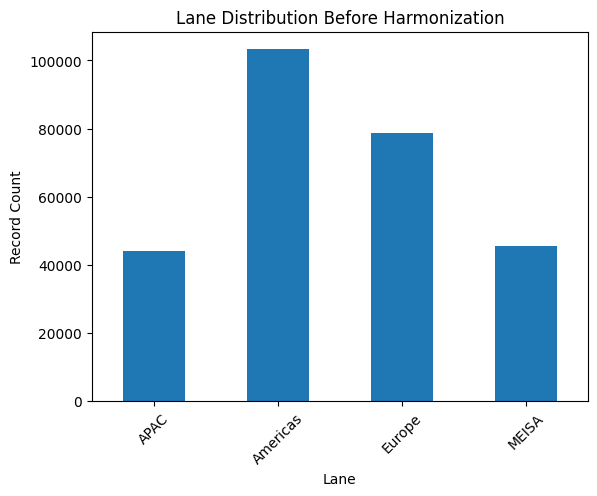

In [8]:
import matplotlib.pyplot as plt

# BEFORE (original Aug Lane column)
before_counts = aug["Lane"].value_counts().sort_index()

plt.figure()
before_counts.plot(kind="bar")
plt.title("Lane Distribution Before Harmonization")
plt.xlabel("Lane")
plt.ylabel("Record Count")
plt.xticks(rotation=45)
plt.show()

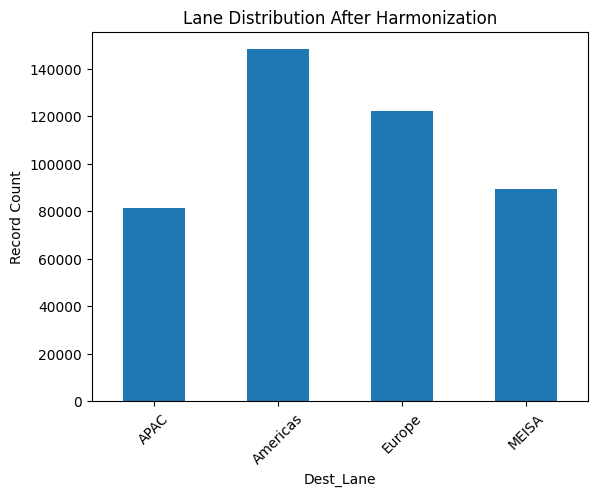

In [27]:
# AFTER (Harmonized Dest_Lane in Bronze)
after_counts = bronze_kpi["Dest_Lane"].value_counts().sort_index()

plt.figure()
after_counts.plot(kind="bar")
plt.title("Lane Distribution After Harmonization")
plt.xlabel("Dest_Lane")
plt.ylabel("Record Count")
plt.xticks(rotation=45)
plt.show()

# Weekly Volume Trend by Lane

<Figure size 640x480 with 0 Axes>

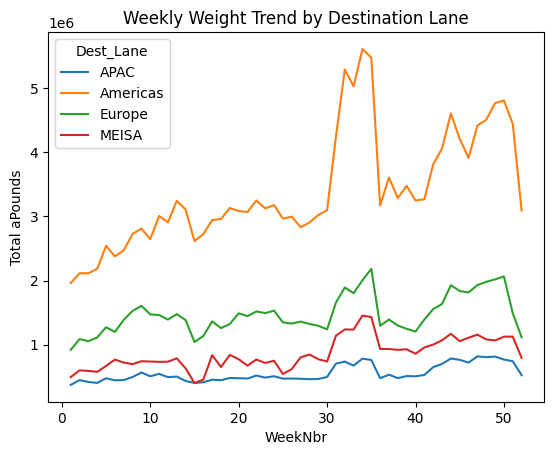

In [30]:
weekly_lane = bronze_full.groupby(["WeekNbr", "Dest_Lane"])["aPounds"].sum().unstack()

plt.figure()
weekly_lane.plot()
plt.title("Weekly Weight Trend by Destination Lane")
plt.xlabel("WeekNbr")
plt.ylabel("Total aPounds")
plt.legend(title="Dest_Lane")
plt.show()